In [156]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

In [157]:
## Disk parameters
alpha = 1e-3
M_disk = 0.1 # M_sun
T_0 = 18.9737 # K
a_c = 50 # AU
a_min = 0.1 # AU
a_max = 1000 # AU
d2g = 0.01
D = 0.2
b_tilde = 10
mu = 2.33
v_frag = 100 # cm/s
epsilon_g = 0.5

## Star parameters
M_star = 1.0 # M_sun
R_star = 2.5 # R_sun
T_eff = 4000 # K

## Planetesimal parameters
rho_pltsml = 2.0 # g/cm^3
R_pltsml = 100 # km

## Embryo core parameters
rho_core = 2.0 # g/cm^3

## Constants
G = 6.67e-8 # cm^3/g/s^2
k_B = 1.38e-16 # erg/K
sigma_B = 5.67e-5 # erg/cm^2/s/K^4
m_H = 1.67e-24 # g
M_earth = 5.97e27 # g
M_sun = 1.99e33 # g
R_sun = 6.96e10 # cm
L_sun = 3.839e33 # erg/s
AU = 1.496e13 # cm
year = 3.156e7 # s
sigma_H2 = 2.61e-15 # cm^2

In [158]:
## Disk structure helper functions

def L_star(R_star, T_eff):
    """Calculates the stellar luminosity in solar luminosities assuming a blackbody."""
    return 4 * np.pi * (R_star * R_sun) ** 2 * sigma_B * T_eff ** 4 / L_sun

def Sigma_0(M_disk, a_c):
    """Calculates the normalization constant for the surface density profile."""
    return M_disk * M_sun / (2 * np.pi * (a_c * AU) ** 2)

def Sigma_g(a):
    """Calculates the gas surface density of the disk in g/cm^2."""
    return Sigma_0(M_disk, a_c) * (a / a_c) ** (-1) * np.exp(-a / a_c)

def Sigma_s(a):
    """Calculates the solid surface density of the disk in g/cm^2."""
    return d2g * Sigma_g(a)

def rho_mid(a):
    """Calculates the midplane gas density of the disk in g/cm^3."""
    return Sigma_g(a) / (np.sqrt(2 * np.pi) * H(a) * AU)

def T(a):
    """Calculates the temperature of the disk in K."""
    return T_0 * (a / a_c) ** (-0.5)

def c_s(a):
    """Calculates the sound speed of the disk in cm/s."""
    return np.sqrt(k_B * T(a) / (mu * m_H))

def H(a):
    """Calculates the scale height of the disk in AU."""
    return c_s(a) / Omega_K(a) / AU

def Reynolds(e2, i2, a):
    """Calculates the Reynolds number."""
    nu_mol = mfp_H2(a) * c_s(a) / 3
    return v_rel(e2, i2, a) * (R_pltsml(a) * 1e5) / nu_mol

def mfp_H2(a):
    """Calculates the mean free path of H2 in cm."""
    n_H2 = rho_mid(a) / (mu * m_H)
    return (n_H2 * sigma_H2) ** (-1)

def P(a):
    """Calculates the pressure of the disk in g/cm/s^2 assuming an ideal gas."""
    return rho_mid(a) * c_s(a) ** 2

def dP_da(a):
    """Calculates the pressure gradient of the disk at a."""
    a_vals = np.logspace(np.log10(a_min), np.log10(a_max), 10000) # AU
    P_vals = P(a_vals)
    dP_da_vals = np.gradient(P_vals, a_vals * AU)
    return np.interp(np.log10(a), np.log10(a_vals), dP_da_vals)

def dlnP_dlna(a):
    """Calculates dlnP/dlna of the disk at a."""
    return (a * AU) / P(a) * dP_da(a)

## Embryo and planetesimal helper functions

def v_rel(e2, i2, a_0):
    """Calculates the relative velocity between planetesimals and the embryo in cm/s (Fortier et al. 2012)."""
    return Omega_K(a_0) * a_0 * AU * np.sqrt(5/8 * e2 + 1/2 * i2)

def R_pltsml(a_0):
    """Calculates the planetesimal radius assuming constant density in km."""
    return (3 * M_pltsml(a_0) * M_earth / (4 * np.pi * rho_core)) ** (1/3) / 1e5

def M_pltsml(a_0):
    """Calculates the planetesimal mass in Earth masses assuming the birth mass from the streaming instability."""
    return M_birth(a_0)

def Omega_K(a):
    """Calculates the Keplerian angular velocity in rad/s."""
    return np.sqrt(G * M_star * M_sun / (a * AU) ** 3)

def R_core(M_core):
    """Calculates the core radius assuming a constant density in km."""
    return (3 * M_core * M_earth / (4 * np.pi * rho_core)) ** (1/3) / 1e5

def R_H(M_core, a_core):
    """Calculates the Hill radius in AU."""
    return a_core * (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def P_scatter(M_core, a_core):
    """Calculates the probbility that a planetesimal is scattered rather than accreted."""
    f_cap = ((2 * G * M_star * M_sun / (a_core * AU)) / (G * M_core * M_earth / (R_core(M_core) * 1e5))) ** 2
    return 1 / (1 + f_cap)

## Streaming instability birth mass

def M_birth(a):
    """Calculates the streaming instability brith mass in Earth masses (Johnston et al 2026)."""
    return 6e-2 * (gamma(a) * np.pi) ** 1.5 * (H(a) / a / 0.05) ** 3 * (M_star / 2.4)

def gamma(a):
    """Calculates the self-gravity parameter (Johnston et al 2026)."""
    return 4 * np.pi * G * rho_mid(a) / (Omega_K(a) ** 2)

## Eccentricity and inclination helper functions

def f_j(a_0, a_j, M_j):
    """Distance modulation function for embryo j (Kaufmann & Alibert 2023)."""
    return 1 / (1 + abs(a_0 - a_j) / (5 * R_H(M_j, a_j)))

def P_VS(e_tilde, i_tilde):
    """Stirring function for eccentricity (Kaufmann & Alibert 2023)."""
    Lambda = 1/12 * (e_tilde ** 2 + i_tilde ** 2) * i_tilde
    beta = i_tilde / e_tilde
    return (73 * e_tilde ** 2) / (10 * Lambda ** 2) * np.log(1 + 10 * Lambda ** 2 / (e_tilde ** 2)) + (72 * I_PVS(beta)) / (np.pi * e_tilde * i_tilde) * np.log(1 + Lambda ** 2)

def Q_VS(e_tilde, i_tilde):
    """Stirring function for inclination (Kaufmann & Alibert 2023)."""
    Lambda = 1/12 * (e_tilde ** 2 + i_tilde ** 2) * i_tilde
    beta = i_tilde / e_tilde
    return (4 * i_tilde ** 2 + 0.2 * i_tilde * e_tilde ** 3) / (10 * Lambda ** 2 * e_tilde) * np.log(1 + 10 * Lambda ** 2 * e_tilde) + (72 * I_QVS(beta)) / (np.pi * e_tilde * i_tilde) * np.log(1 + Lambda ** 2)

def I_PVS(beta):
    """Numerical elliptic integral approximation (Kaufmann & Alibert 2023)."""
    return (beta - 0.36251) / (0.061547 + 0.16112 * beta + 0.054473 * beta ** 2)

def I_QVS(beta):
    """Numerical elliptic integral approximation (Kaufmann & Alibert 2023)."""
    return (0.71946 - beta) / (0.21239 + 0.49764 * beta + 0.14369 * beta ** 2)

def t_stop(e2, i2, a_0):
    """Planetesimal gas drag stopping time in s (Kaufmann & Alibert 2023)."""

    if R_pltsml(a_0) * 1e5 < 1.5 * mfp_H2(a_0):
        return rho_pltsml * (R_pltsml(a_0) * 1e5) / (rho_mid(a_0) * c_s(a_0))
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return 2 * rho_pltsml * (R_pltsml(a_0) * 1e5) ** 2 / (3 * rho_mid(a_0) * mfp_H2(a_0) * c_s(a_0))
        
        else:
            return 6 * rho_pltsml * (R_pltsml(a_0) * 1e5) / (rho_mid(a_0) * v_rel(e2, i2, a_0))

def e_tilde_embryo(e2, M_core):
    """Calculates the embryo reduced eccentricity."""
    return np.sqrt(np.maximum(e2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_embryo(i2, M_core):
    """Calculates the embryo reduced inclination."""
    return np.sqrt(np.maximum(i2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def e_tilde_pltsml(e2, a_0):
    """Calculates the planetesimal reduced eccentricity."""
    return 2 * np.sqrt(np.maximum(e2, 0)) / (2 * M_pltsml(a_0) * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_pltsml(i2, a_0):
    """Calculates the planetesimal reduced inclination."""
    return 2 * np.sqrt(np.maximum(i2, 0)) / (2 * M_pltsml(a_0) * M_earth / (3 * M_star * M_sun)) ** (1/3)

## Planetesimal accretion helper functions

def I_F(beta):
    """Numerical elliptic integral approximation (Fortier et al 2012)."""
    return (1 + 0.95925 * beta + 0.77251 * beta ** 2) / (beta * (0.13142 + 0.12295 * beta))

def I_G(beta):
    """Numerical elliptic integral approximation (Fortier et al 2012)."""
    return (1 + 0.3996 * beta) / (beta * (0.0369 + 0.048333 * beta + 0.006874 * beta ** 2))

def P_high(e2, i2, a_core, M_core):
    """Calculates the high collisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return ((R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5) ** 2 / (2 * np.pi * (R_H(M_core, a_core) * AU) ** 2)) * (I_F(beta) + 6 * R_H(M_core, a_core) * AU * I_G(beta) / ((R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5) * e_tilde ** 2))

def P_med(e2, i2, a_core, M_core):
    """Calculates the medium collisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return ((R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5) ** 2 / (4 * np.pi * (R_H(M_core, a_core) * AU) ** 2) * i_tilde) * (17.3 + 232 * R_H(M_core, a_core) * AU / (R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5))

def P_low(e2, i2, a_core, M_core):
    """Calculates the low colisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return 11.3 * ((R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5) / (R_H(M_core, a_core) * AU)) ** (1/2)

def P_coll(e2, i2, a_core, M_core):
    """Calculates the probability that the planetesimal is accreted by the embryo (Fortier et al 2012)."""
    return np.min((P_med(e2, i2, a_core, M_core), (P_high(e2, i2, a_core, M_core) ** (-2) + P_low(e2, i2, a_core, M_core) ** (-2)) ** (-1/2)), axis = 0)

In [159]:
## Pebble accretion onset mass

def M_on(a):
    """Calculates the onset mass for pebble accretion in Earth masses (Lorek et al 2022)."""
    return 4.871e-7 * (tau_s(a) / 0.01) * M_star ** (-17/7) * L_star(R_star, T_eff) ** (6/7) * a ** (12/7)

def tau_s(a):
    """Calculates the Stokes number (Lorek et al 2022)."""
    return np.min((tau_s_frag(a), tau_s_drift(a)), axis = 0)

def tau_s_frag(a):
    """Calculates the fragmentation limited Stokes number (Lorek et al 2022)."""
    return v_frag ** 2 / (2 * alpha * c_s(a) ** 2)

def tau_s_drift(a):
    """Calculates the drift limited Stokes number (Lorek et al 2022)."""
    return 3 * np.sqrt(np.pi) / 4 * epsilon_g * d2g / eta(a)

def eta(a):
    """Calculates the eta parameter (Fortier et al 2012)."""
    return -1 * dP_da(a) / (2 * Omega_K(a) ** 2 * a * AU * rho_mid(a))

## Pebble accretion transition mass

def M_tr(a):
    """Calculates the transition mass from the Bondi to the Hill regime in Earth masses (Lorek et al 2022)."""
    return 1.125e-4 * M_star ** (-17/7) * L_star(R_star, T_eff) ** (6/7) * a ** (12/7)

## Pebble isolation mass

def M_iso_pebble(a):
    """Calculates the pebble isolation mass in Earth masses (Lorek et al 2022)."""
    return 25 * (H(a) / a / 0.05) ** 3 * (0.34 * (-3 / np.log10(alpha)) ** 4 + 0.66 ) * (1 - (dlnP_dlna(a) + 2.5) / 6)

## Planetesimal isolation mass

def M_iso_pltsml(a):
    """Calculates the planetesimal isolation mass in Earth masses (Rafikov 2011)."""
    return (2 * np.pi * (a * AU) ** 2 * b_tilde * Sigma_s(a)) ** (3/2) * (3 * M_star * M_sun) ** (-1/2) / M_earth

In [160]:
def extra_plots(a_vals, results, figure_dir, drag = True, VS_embryo = True, VS_pltsml = True, DF = True, accretion = True, scatter = False):

    fig1, ax1 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # e(t)
    fig2, ax2 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # i(t)
    fig3, ax3 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # de2/dt(t)
    fig4, ax4 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # di2/dt(t)
    fig5, ax5 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # M(t)
    fig6, ax6 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # dM/dt(t)
    fig7, ax7 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # v_rel(t)
    fig8, ax8 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # M(v_rel)
    fig9, ax9 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # dM/dt(v_rel)
    fig10, ax10 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # dM/dt(M)
    fig11, ax11 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # v_rel(M)
    fig12, ax12 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # P_coll vs t
    fig13, ax13 = plt.subplots(1, len(a_vals), figsize = (8 * len(a_vals), 6), squeeze = False) # P_scatter vs t

    for j in range(len(a_vals)):

        ## Unpack results
        a_0 = a_vals[j]
        t_Myr = results[a_0]['t_Myr']

        ## Eccentricity
        e = results[a_0]['e']
        e2 = results[a_0]['e2']
        e_drag = results[a_0]['e_terms']['drag']
        e_VS_embryo = results[a_0]['e_terms']['VS_embryo']
        e_VS_pltsml = results[a_0]['e_terms']['VS_pltsml']
        e_DF = results[a_0]['e_terms']['DF']

        ## Inclination
        i = results[a_0]['i']
        i2 = results[a_0]['i2']
        i_drag = results[a_0]['i_terms']['drag']
        i_VS_embryo = results[a_0]['i_terms']['VS_embryo']
        i_VS_pltsml = results[a_0]['i_terms']['VS_pltsml']
        i_DF = results[a_0]['i_terms']['DF']

        ## Eccentricity derivatives
        e2_dot = results[a_0]['e2_dot']
        e2_dot_drag = results[a_0]['e2_dot_terms']['drag']
        e2_dot_VS_embryo = results[a_0]['e2_dot_terms']['VS_embryo']
        e2_dot_VS_pltsml = results[a_0]['e2_dot_terms']['VS_pltsml']
        e2_dot_DF = results[a_0]['e2_dot_terms']['DF']

        ## Inclination derivatives
        i2_dot = results[a_0]['i2_dot']
        i2_dot_drag = results[a_0]['i2_dot_terms']['drag']
        i2_dot_VS_embryo = results[a_0]['i2_dot_terms']['VS_embryo']
        i2_dot_VS_pltsml = results[a_0]['i2_dot_terms']['VS_pltsml']
        i2_dot_DF = results[a_0]['i2_dot_terms']['DF']

        ## Mass and accretion rate
        M = results[a_0]['M']
        M_dot = results[a_0]['M_dot']

        ## Velocity dispersion
        v_rel = results[a_0]['v_rel']

        ## Collision rates
        P_low_vals = P_low(e2, i2, a_0, M)
        P_med_vals = P_med(e2, i2, a_0, M)
        P_high_vals = P_high(e2, i2, a_0, M)
        P_coll_vals = P_coll(e2, i2, a_0, M)

        ## Accretion rates
        M_dot_low = Sigma_s(a_0) * Omega_K(a_0) * (R_H(M, a_0) * AU) ** 2 * P_low(e2, i2, a_0, M) / M_earth
        M_dot_med = Sigma_s(a_0) * Omega_K(a_0) * (R_H(M, a_0) * AU) ** 2 * P_med(e2, i2, a_0, M) / M_earth
        M_dot_high = Sigma_s(a_0) * Omega_K(a_0) * (R_H(M, a_0) * AU) ** 2 * P_high(e2, i2, a_0, M) / M_earth

        ## Scatter Probability
        P_scat = P_scatter(M, a_0)
        P_capt = np.ones_like(t_Myr) - P_scat

        ## Figure 1: e vs t
        
        ax1[0, j].plot(t_Myr, np.where(e > 0, e, np.nan), color = 'k', linestyle = '-', label = r'$e(t)$')
        ax1[0, j].plot(t_Myr, np.where(e < 0, -1 * e, np.nan), color = 'k', linestyle = '--')

        ## Drag
        if drag:
            ax1[0, j].plot(t_Myr, np.where(e_drag > 0, e_drag, np.nan), color = 'tab:blue', linestyle = '-', label = 'Drag')
            ax1[0, j].plot(t_Myr, np.where(e_drag < 0, -1 * e_drag, np.nan), color = 'tab:blue', linestyle = '--')

        ## VS_embryo
        if VS_embryo:
            ax1[0, j].plot(t_Myr, np.where(e_VS_embryo > 0, e_VS_embryo, np.nan), color = 'tab:red', linestyle = '-', label = 'Embryo Stirring')
            ax1[0, j].plot(t_Myr, np.where(e_VS_embryo < 0, -1 * e_VS_embryo, np.nan), color = 'tab:red', linestyle = '--')

        ## VS_pltsml
        if VS_pltsml:
            ax1[0, j].plot(t_Myr, np.where(e_VS_pltsml > 0, e_VS_pltsml, np.nan), color = 'tab:orange', linestyle = '-', label = 'Planetesimal Stirring')
            ax1[0, j].plot(t_Myr, np.where(e_VS_pltsml < 0, -1 * e_VS_pltsml, np.nan), color = 'tab:orange', linestyle = '--')

        ## DF
        if DF:
            ax1[0, j].plot(t_Myr, np.where(e_DF > 0, e_DF, np.nan), color = 'tab:green', linestyle = '-', label = 'Density Fluctuations')
            ax1[0, j].plot(t_Myr, np.where(e_DF < 0, -1 * e_DF, np.nan), color = 'tab:green', linestyle = '--')

        ax1[0, j].axhline(e[0], color = 'grey', linestyle = '--', label = r'$e_{eq}$')

        ax1[0, j].set_yscale('log')
        ax1[0, j].set_xlabel(r't [Myr]')
        ax1[0, j].set_ylabel(r'$e$')
        ax1[0, j].set_title(fr'$e(t)$: {a_0} AU')
        ax1[0, j].margins(0)
        ax1[0, j].legend()

        ## Figure 2: i vs t

        ax2[0, j].plot(t_Myr, np.where(i > 0, i, np.nan), color = 'k', linestyle = '-', label = r'$i(t)$')
        ax2[0, j].plot(t_Myr, np.where(i < 0, -1 * i, np.nan), color = 'k', linestyle = '--')

        ## Drag
        if drag:
            ax2[0, j].plot(t_Myr, np.where(i_drag > 0, i_drag, np.nan), color = 'tab:blue', linestyle = '-', label = 'Drag')
            ax2[0, j].plot(t_Myr, np.where(i_drag < 0, -1 * i_drag, np.nan), color = 'tab:blue', linestyle = '--')

        ## VS_embryo
        if VS_embryo:
            ax2[0, j].plot(t_Myr, np.where(i_VS_embryo > 0, i_VS_embryo, np.nan), color = 'tab:red', linestyle = '-', label = 'Embryo Stirring')
            ax2[0, j].plot(t_Myr, np.where(i_VS_embryo < 0, -1 * i_VS_embryo, np.nan), color = 'tab:red', linestyle = '--')

        ## VS_pltsml
        if VS_pltsml:
            ax2[0, j].plot(t_Myr, np.where(i_VS_pltsml > 0, i_VS_pltsml, np.nan), color = 'tab:orange', linestyle = '-', label = 'Planetesimal Stirring')
            ax2[0, j].plot(t_Myr, np.where(i_VS_pltsml < 0, -1 * i_VS_pltsml, np.nan), color = 'tab:orange', linestyle = '--')

        ## DF
        if DF:
            ax2[0, j].plot(t_Myr, np.where(i_DF > 0, i_DF, np.nan), color = 'tab:green', linestyle = '-', label = 'Density Fluctuations')
            ax2[0, j].plot(t_Myr, np.where(i_DF < 0, -1 * i_DF, np.nan), color = 'tab:green', linestyle = '--')

        ax2[0, j].axhline(i[0], color = 'grey', linestyle = '--', label = r'$i_{eq}$')

        ax2[0, j].set_yscale('log')
        ax2[0, j].set_xlabel(r't [Myr]')
        ax2[0, j].set_ylabel(r'$i$')
        ax2[0, j].set_title(fr'$i(t)$: {a_0} AU')
        ax2[0, j].margins(0)
        ax2[0, j].legend()

        ## Figure 3: de2/dt vs t

        ax3[0, j].plot(t_Myr, np.where(e2_dot * year > 0, e2_dot * year, np.nan), color = 'k', linestyle = '-', label = r'$\dot e^2(t)$')
        ax3[0, j].plot(t_Myr, np.where(e2_dot * year < 0, -1 * e2_dot * year, np.nan), color = 'k', linestyle = '--')
        
        ## Drag
        if drag:
            ax3[0, j].plot(t_Myr, np.where(e2_dot_drag * year > 0, e2_dot_drag * year, np.nan), color = 'tab:blue', linestyle = '-', label = 'Drag')
            ax3[0, j].plot(t_Myr, np.where(e2_dot_drag * year < 0, -1 * e2_dot_drag * year, np.nan), color = 'tab:blue', linestyle = '--')

        ## VS_embryo
        if VS_embryo:
            ax3[0, j].plot(t_Myr, np.where(e2_dot_VS_embryo * year > 0, e2_dot_VS_embryo * year, np.nan), color = 'tab:red', linestyle = '-', label = 'Embryo Stirring')
            ax3[0, j].plot(t_Myr, np.where(e2_dot_VS_embryo * year < 0, -1 * e2_dot_VS_embryo * year, np.nan), color = 'tab:red', linestyle = '--')

        ## VS_pltsml
        if VS_pltsml:
            ax3[0, j].plot(t_Myr, np.where(e2_dot_VS_pltsml * year > 0, e2_dot_VS_pltsml * year, np.nan), color = 'tab:orange', linestyle = '-', label = 'Planetesimal Stirring')
            ax3[0, j].plot(t_Myr, np.where(e2_dot_VS_pltsml * year < 0, -1 * e2_dot_VS_pltsml * year, np.nan), color = 'tab:orange', linestyle = '--')

        ## DF
        if DF:
            ax3[0, j].plot(t_Myr, np.where(e2_dot_DF * year > 0, 1 * e2_dot_DF * year, np.nan), color = 'tab:green', linestyle = '-', label = 'Density Fluctuations')
            ax3[0, j].plot(t_Myr, np.where(e2_dot_DF * year < 0, -1 * e2_dot_DF * year, np.nan), color = 'tab:green', linestyle = '--')

        ax3[0, j].set_ylim(1e-18, 1e-4)
        ax3[0, j].set_yscale('log')
        ax3[0, j].set_xlabel(r't [Myr]')
        ax3[0, j].set_ylabel(r'$de^2/dt$ [year$^{-1}$]')
        ax3[0, j].set_title(fr'$\dot e^2$: {a_0} AU')
        ax3[0, j].margins(0)
        ax3[0, j].legend()

        ## Figure 4: di2/dt vs t

        ax4[0, j].plot(t_Myr, np.where(i2_dot * year > 0, i2_dot * year, np.nan), color = 'k', linestyle = '-', label = r'$\dot i^2(t)$')
        ax4[0, j].plot(t_Myr, np.where(i2_dot * year < 0, -1 * i2_dot * year, np.nan), color = 'k', linestyle = '--')
        
        ## Drag
        if drag:
            ax4[0, j].plot(t_Myr, np.where(i2_dot_drag * year > 0, i2_dot_drag * year, np.nan), color = 'tab:blue', linestyle = '-', label = 'Drag')
            ax4[0, j].plot(t_Myr, np.where(i2_dot_drag * year < 0, -1 * i2_dot_drag * year, np.nan), color = 'tab:blue', linestyle = '--')

        ## VS_embryo
        if VS_embryo:
            ax4[0, j].plot(t_Myr, np.where(i2_dot_VS_embryo * year > 0, i2_dot_VS_embryo * year, np.nan), color = 'tab:red', linestyle = '-', label = 'Embryo Stirring')
            ax4[0, j].plot(t_Myr, np.where(i2_dot_VS_embryo * year < 0, -1 * i2_dot_VS_embryo * year, np.nan), color = 'tab:red', linestyle = '--')

        ## VS_pltsml
        if VS_pltsml:
            ax4[0, j].plot(t_Myr, np.where(i2_dot_VS_pltsml * year > 0, i2_dot_VS_pltsml * year, np.nan), color = 'tab:orange', linestyle = '-', label = 'Planetesimal Stirring')
            ax4[0, j].plot(t_Myr, np.where(i2_dot_VS_pltsml * year < 0, -1 * i2_dot_VS_pltsml * year, np.nan), color = 'tab:orange', linestyle = '--')

        ## DF
        if DF:
            ax4[0, j].plot(t_Myr, np.where(i2_dot_DF * year > 0, 1 * i2_dot_DF * year, np.nan), color = 'tab:green', linestyle = '-', label = 'Density Fluctuations')
            ax4[0, j].plot(t_Myr, np.where(i2_dot_DF * year < 0, -1 * i2_dot_DF * year, np.nan), color = 'tab:green', linestyle = '--')

        ax4[0, j].set_ylim(1e-18, 1e-4)
        ax4[0, j].set_yscale('log')
        ax4[0, j].set_xlabel(r't [Myr]')
        ax4[0, j].set_ylabel(r'$di^2/dt$ [year$^{-1}$]')
        ax4[0, j].set_title(fr'$\dot i^2$: {a_0} AU')
        ax4[0, j].margins(0)
        ax4[0, j].legend()

        ## Figure 5: M vs t

        ax5[0, j].plot(t_Myr, M, color = 'k')
        ax5[0, j].axhline(M[0], color = 'k', linestyle = '--', label = r'$M_{init}$')
        ax5[0, j].axhline(M_iso_pltsml(a_0), color = 'k', linestyle = 'dotted', label = r'$M_{iso, pltsml}$')

        ax5[0, j].axhspan(1e-8, M_on(a_0), color = 'red', alpha = 0.5, label = r'$M < M_{on}$')
        ax5[0, j].axhspan(M_on(a_0), M_tr(a_0), color = 'yellow', alpha = 0.5, label = r'$M < M_{tr}$')
        ax5[0, j].axhspan(M_tr(a_0), M_iso_pebble(a_0), color = 'green', alpha = 0.5, label = r'$M < M_{iso, pebble}$')
        ax5[0, j].axhspan(M_iso_pebble(a_0), 1e4, color = 'red', alpha = 0.5, label = r'$M > M_{iso, pebble}$')

        ax5[0, j].set_ylim(1e-8, 1e4)
        ax5[0, j].set_yscale('log')
        ax5[0, j].set_xlabel(r't [Myr]')
        ax5[0, j].set_ylabel(r'$M_{core}$ [$M_\oplus$]')
        ax5[0, j].set_title(fr'$M(t)$: {a_0} AU')
        ax5[0, j].margins(0)
        ax5[0, j].legend()

        ## Figure 6: dM/dt vs t

        ax6[0, j].plot(t_Myr, M_dot * year, color = 'k', label = r'$\dot M_{core}(t)$')
        ax6[0, j].plot(t_Myr, M_dot_low * year, color = 'tab:blue', linestyle = 'dotted', label = r'$\dot M_{core, low}(t)$')
        ax6[0, j].plot(t_Myr, M_dot_med * year, color = 'tab:orange', linestyle = 'dotted', label = r'$\dot M_{core, med}(t)$')
        ax6[0, j].plot(t_Myr, M_dot_high * year, color = 'tab:green', linestyle = 'dotted', label = r'$\dot M_{core, high}(t)$')

        ax6[0, j].set_yscale('log')
        ax6[0, j].set_xlabel(r't [Myr]')
        ax6[0, j].set_ylabel(r'$\dot M_{core}$ [$M_\oplus$/year]')
        ax6[0, j].set_title(fr'$\dot M(t)$: {a_0} AU')
        ax6[0, j].margins(0)
        ax6[0, j].legend()

        ## Figure 7: v_rel vs t

        ax7[0, j].plot(t_Myr, v_rel, color = 'k')
        ax7[0, j].set_yscale('log')
        ax7[0, j].set_xlabel(r't [Myr]')
        ax7[0, j].set_ylabel(r'$v_{rel}$ [cm/s]')
        ax7[0, j].set_title(fr'$v_{{rel}}(t)$: {a_0} AU')
        ax7[0, j].margins(0)

        ## Figure 8: M vs v_rel

        ax8[0, j].plot(v_rel, M, color = 'k')
        ax8[0, j].set_xscale('log')
        ax8[0, j].set_xlabel(r'$v_{rel}$ [cm/s]')
        ax8[0, j].set_ylabel(r'$M_{core}$ [$M_\oplus$]')
        ax8[0, j].set_title(fr'$M(v_{{rel}})$: {a_0} AU')
        ax8[0, j].margins(0)

        ## Figure 9: dM/dt vs v_rel

        ax9[0, j].plot(v_rel, M_dot * year, color = 'k')
        ax9[0, j].set_xscale('log')
        ax9[0, j].set_yscale('log')
        ax9[0, j].set_xlabel(r'$v_{rel}$ [cm/s]')
        ax9[0, j].set_ylabel(r'$\dot M_{core}$ [$M_\oplus$/year]')
        ax9[0, j].set_title(fr'$\dot M(v_{{rel}})$: {a_0} AU')
        ax9[0, j].margins(0)

        ## Figure 10: dM/dt vs M

        ax10[0, j].plot(M, M_dot * year, color = 'k')
        ax10[0, j].set_xscale('log')
        ax10[0, j].set_yscale('log')
        ax10[0, j].set_xlabel(r'$M_{core}$ [$M_\oplus$]')
        ax10[0, j].set_ylabel(r'$\dot M_{core}$ [$M_\oplus$/year]')
        ax10[0, j].set_title(fr'$\dot M(M)$: {a_0} AU')
        ax10[0, j].margins(0)

        ## Figure 11: v_rel vs M

        ax11[0, j].plot(M, v_rel, color = 'k')
        ax11[0, j].set_xlabel(r'$M_{core}$ [$M_\oplus$]')
        ax11[0, j].set_ylabel(r'$v_{rel}$ [cm/s]')
        ax11[0, j].set_title(fr'$v_{{rel}}(M)$: {a_0} AU')
        ax11[0, j].margins(0)

        ## Figure 12: P_coll vs t

        ax12[0, j].plot(t_Myr, P_low_vals, color = 'tab:blue', label = r'$P_{low}$')
        ax12[0, j].plot(t_Myr, P_med_vals, color = 'tab:orange', label = r'$P_{med}$')
        ax12[0, j].plot(t_Myr, P_high_vals, color = 'tab:green', label = r'$P_{high}$')
        ax12[0, j].plot(t_Myr, P_coll_vals, color = 'k', linestyle = '--', label = r'$P_{coll}$')

        ax12[0, j].set_ylim(1e-6, 1e2)
        ax12[0, j].set_yscale('log')
        ax12[0, j].set_xlabel(r'$M_c$ [$M_\oplus$]')
        ax12[0, j].set_ylabel(r'Collision Rates')
        ax12[0, j].set_title(f'$P_{{coll}}(t)$: {a_0} AU')
        ax12[0, j].margins(0)
        ax12[0, j].legend()

        ## Figure 13: P_scatter vs t

        ax13[0, j].plot(t_Myr, P_scat, color = 'tab:blue', label = r'$P_{scatter}$')
        ax13[0, j].plot(t_Myr, P_capt, color = 'tab:orange', label = r'$P_{capture}$')

        ax13[0, j].set_yscale('log')
        ax13[0, j].set_xlabel(r't [Myr]')
        ax13[0, j].set_ylabel(r'Probability')
        ax13[0, j].set_title(f'$P_{{scatter}}(t)$: {a_0} AU')
        ax13[0, j].legend()

    ## Save figures

    fig1.tight_layout()
    fig1.savefig(f'{figure_dir}e_vs_t.png', bbox_inches = 'tight')

    fig2.tight_layout()
    fig2.savefig(f'{figure_dir}i_vs_t.png', bbox_inches = 'tight')

    fig3.tight_layout()
    fig3.savefig(f'{figure_dir}de2dt_vs_t.png', bbox_inches = 'tight')

    fig4.tight_layout()
    fig4.savefig(f'{figure_dir}di2dt_vs_t.png', bbox_inches = 'tight')

    fig5.tight_layout()
    fig5.savefig(f'{figure_dir}M_vs_t.png', bbox_inches = 'tight')

    fig6.tight_layout()
    fig6.savefig(f'{figure_dir}dMdt_vs_t.png', bbox_inches = 'tight')

    fig7.tight_layout()
    fig7.savefig(f'{figure_dir}vrel_vs_t.png', bbox_inches = 'tight')

    fig8.tight_layout()
    fig8.savefig(f'{figure_dir}M_vs_vrel.png', bbox_inches = 'tight')

    fig9.tight_layout()
    fig9.savefig(f'{figure_dir}dMdt_vs_vrel', bbox_inches = 'tight')

    fig10.tight_layout()
    fig10.savefig(f'{figure_dir}dMdt_vs_M.png', bbox_inches = 'tight')

    fig11.tight_layout()
    fig11.savefig(f'{figure_dir}vrel_vs_M.png', bbox_inches = 'tight')

    fig12.tight_layout()
    fig12.savefig(f'{figure_dir}Pcoll_vs_t.png', bbox_inches = 'tight')

    fig13.tight_layout()
    fig13.savefig(f'{figure_dir}Pscatter_vs_t.png', bbox_inches = 'tight')

    plt.show()

In [161]:
def load_results(output_dir):
    """Loads results from an HDF5 file and returns a nested dictionary."""

    results = {}

    with h5py.File(output_dir, "r") as h5f:

        for a_key in h5f.keys():
            a = float(a_key)
            results[a] = {}

            for key in h5f[a_key].keys():
                item = h5f[a_key][key]

                if isinstance(item, h5py.Dataset):
                    results[a][key] = item[()]

                elif isinstance(item, h5py.Group):
                    results[a][key] = {}

                    for subkey in item.keys():
                        results[a][key][subkey] = item[subkey][()]

    return results

Loading results from "/Users/ben/Downloads/Planet Formation/Bern Model Simulations/Output/ncores_11_Mdisk_0.1_tend_10.0.h5"...
Plotting results and saving figures to "/Users/ben/Downloads/Planet Formation/Bern Model Simulations/Figures/ncores_11_Mdisk_0.1_tend_10.0/Extra Plots/"...


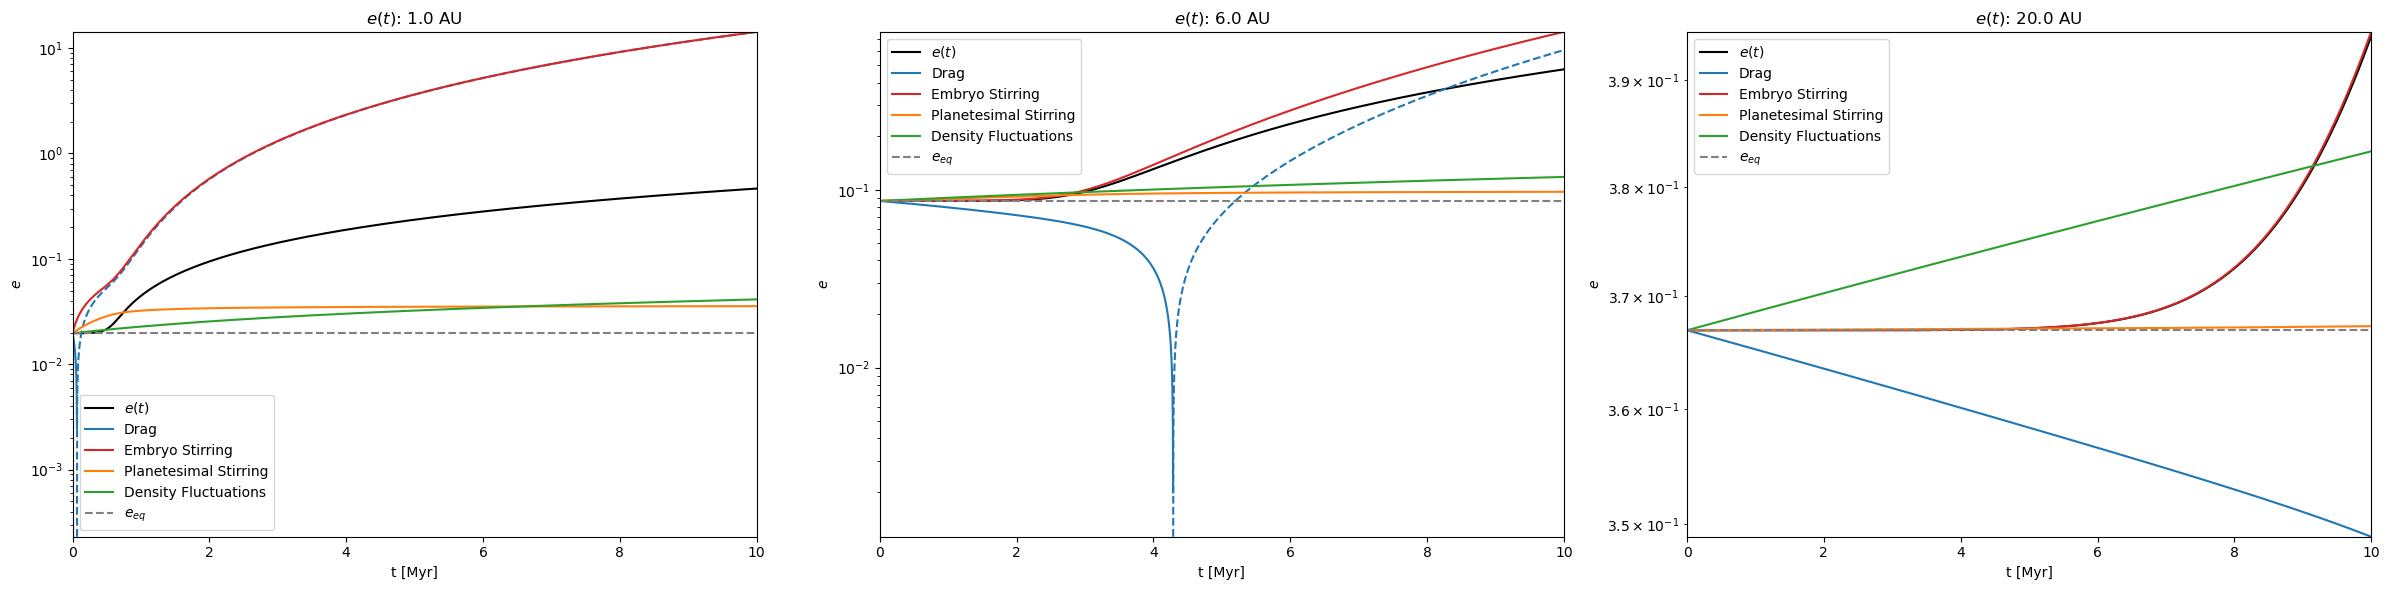

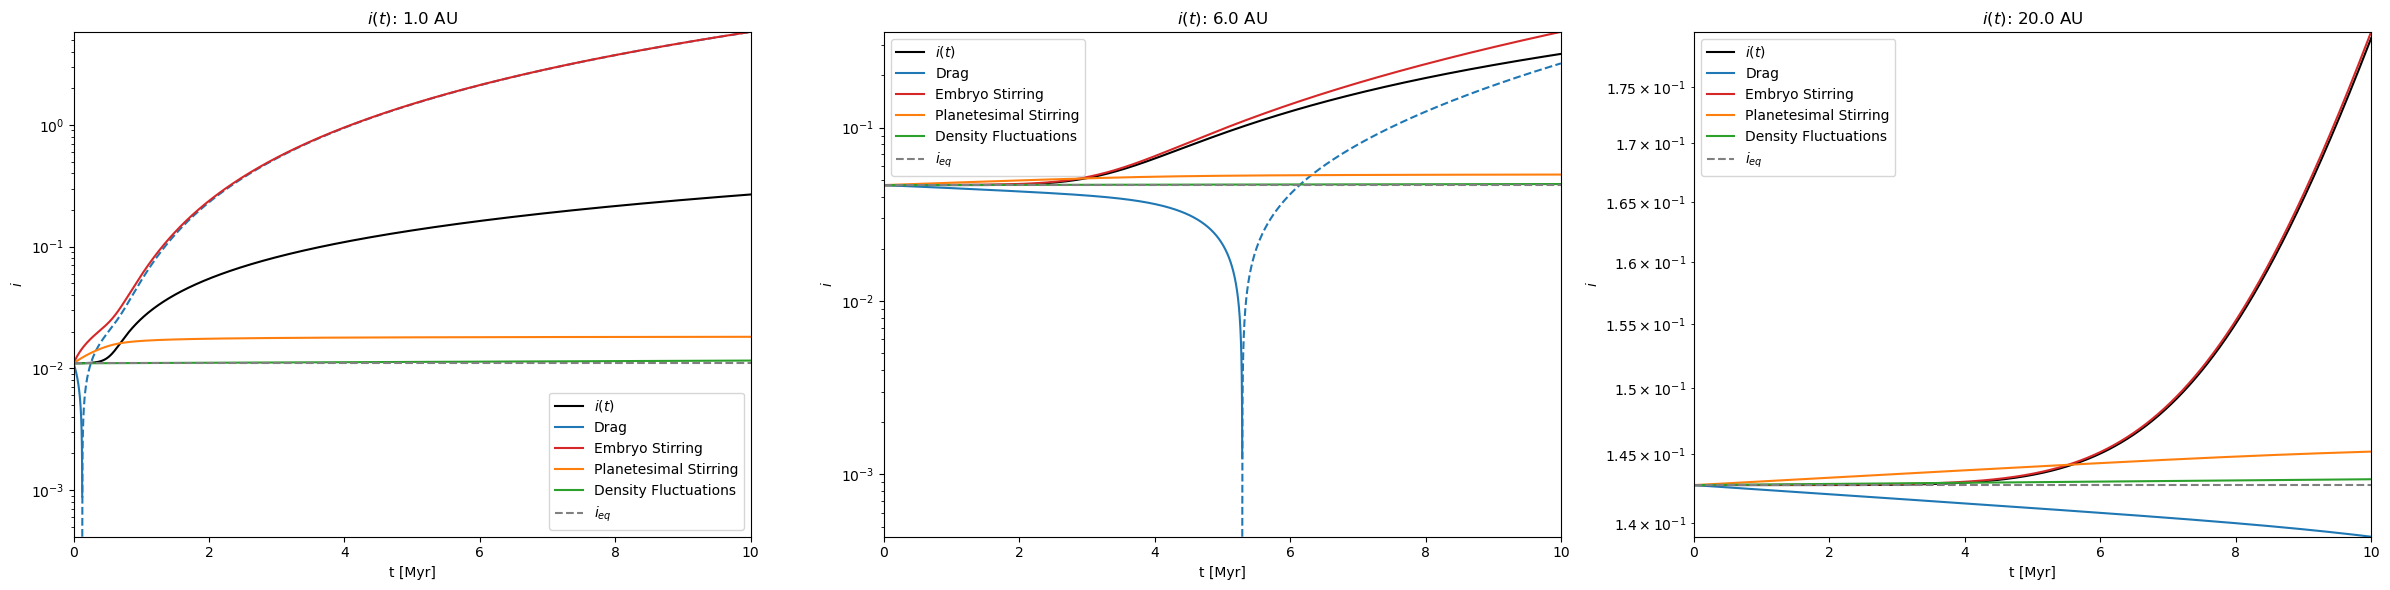

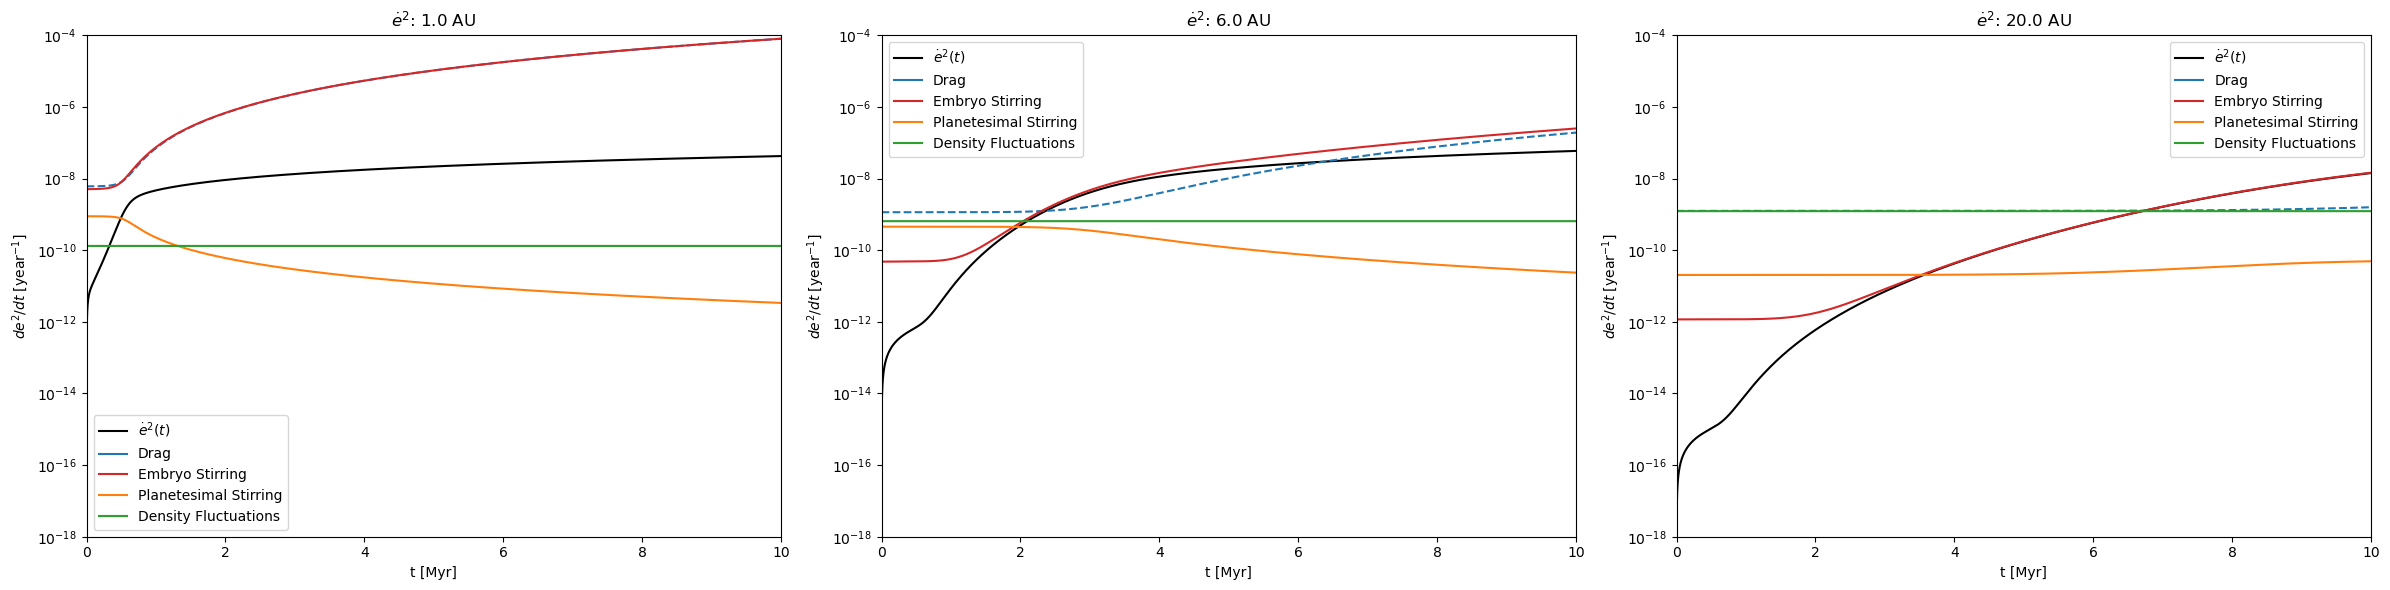

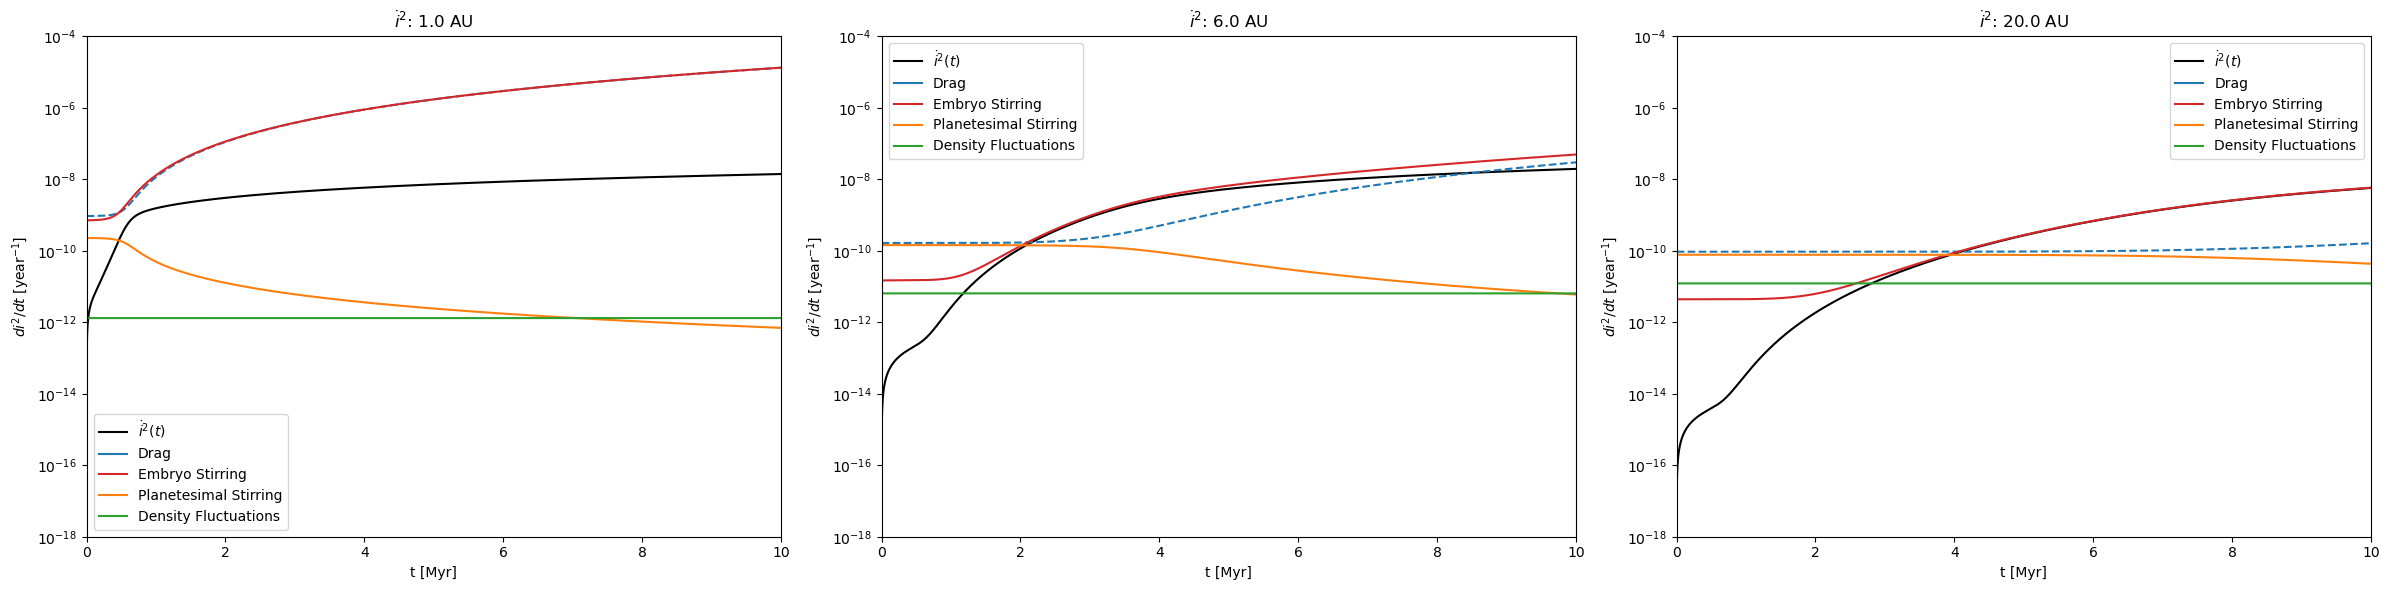

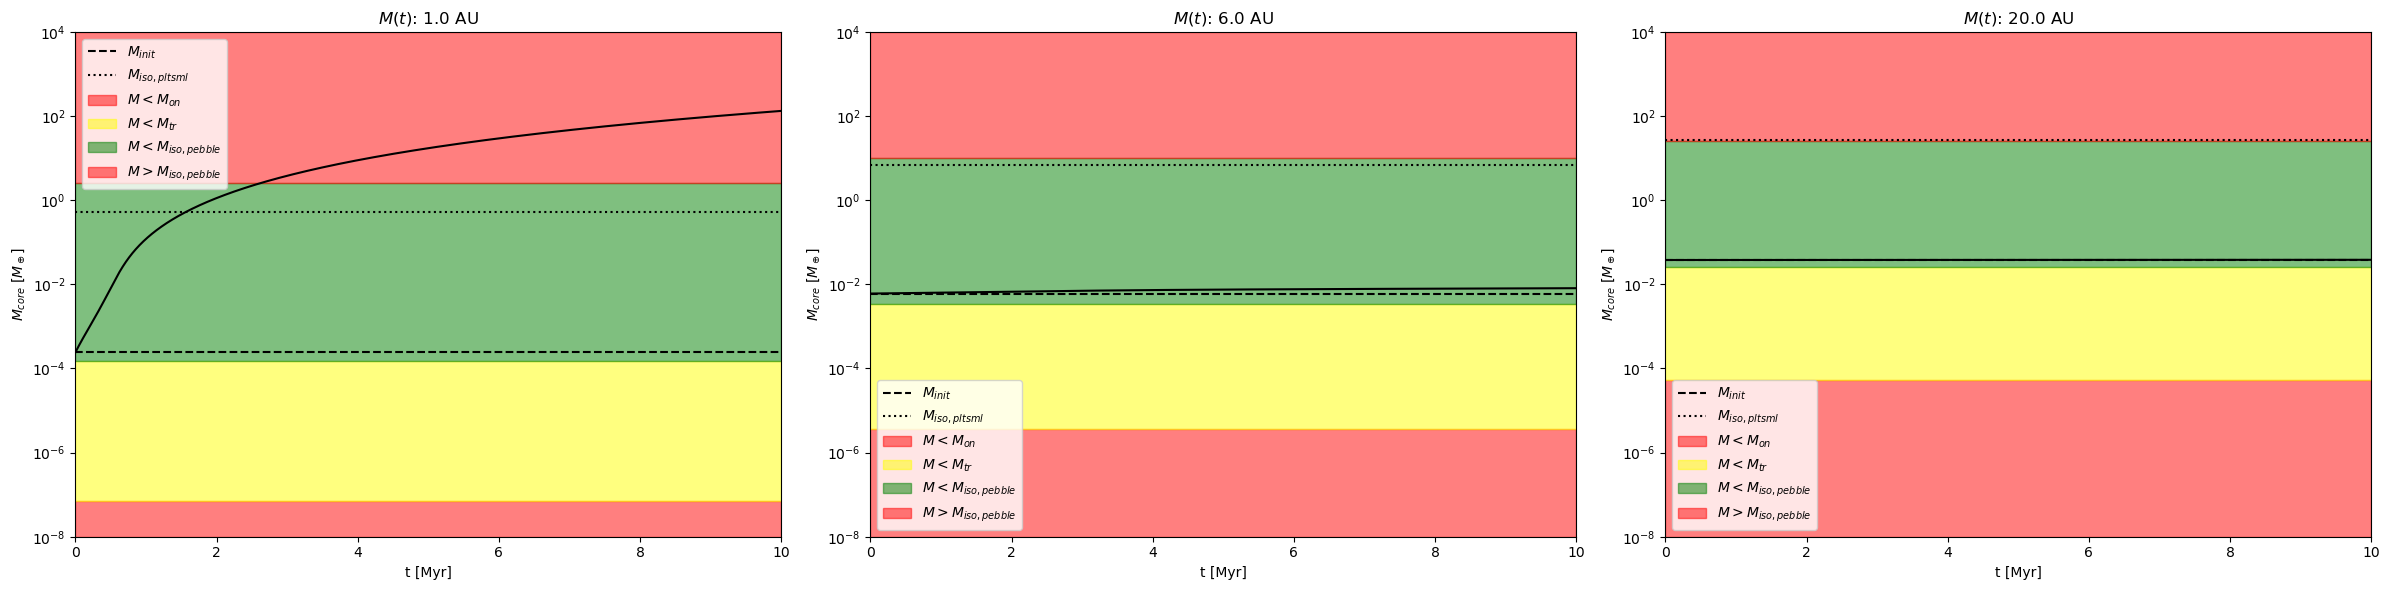

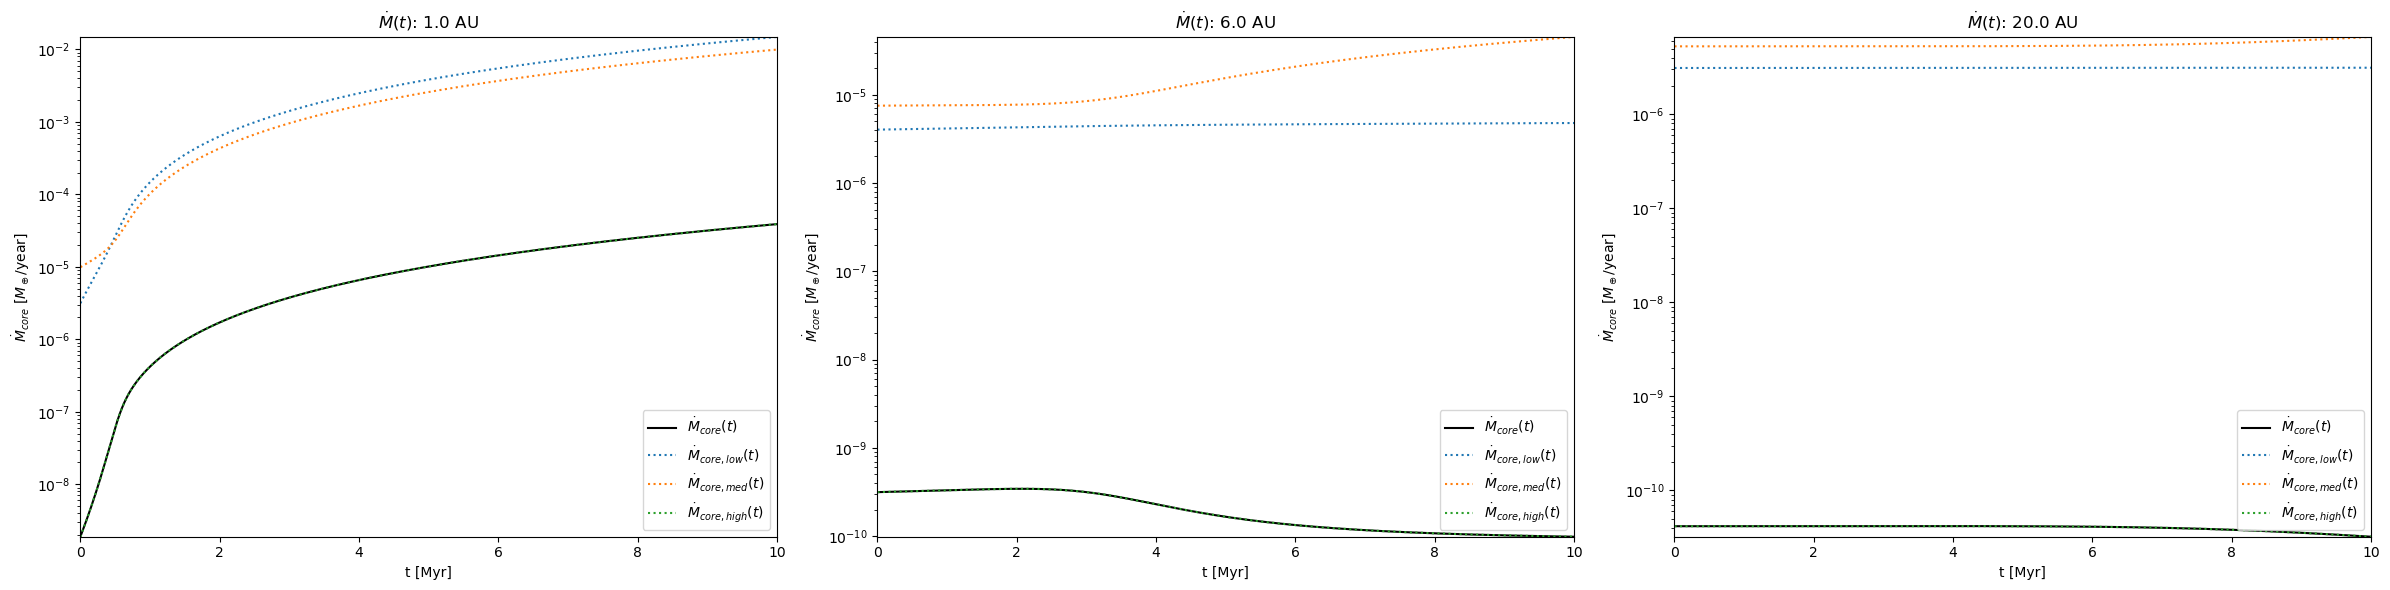

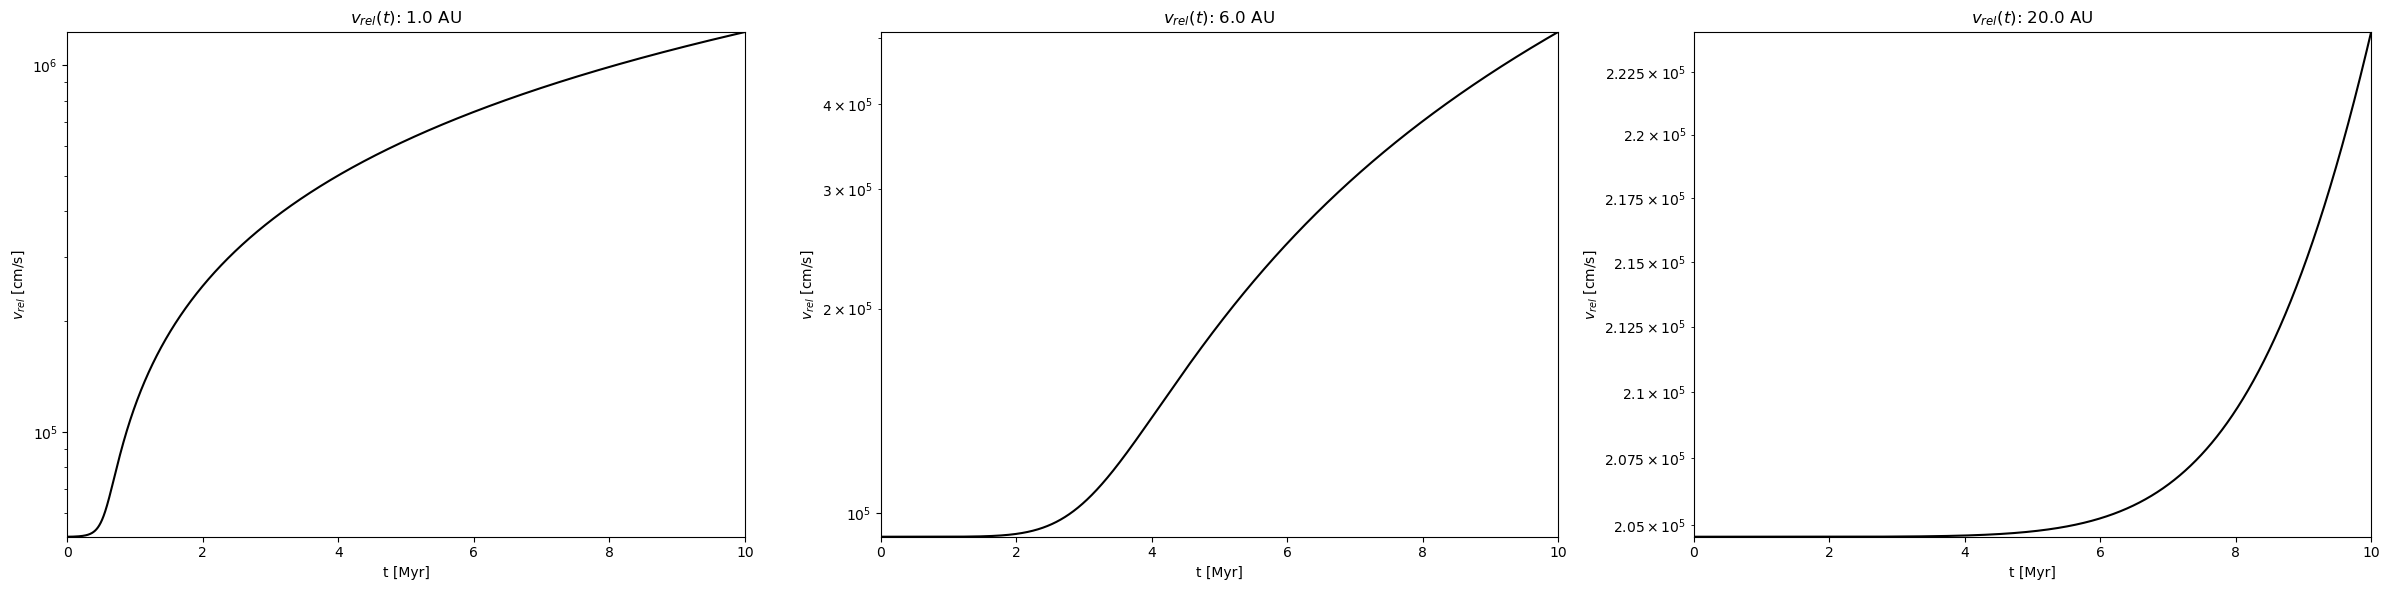

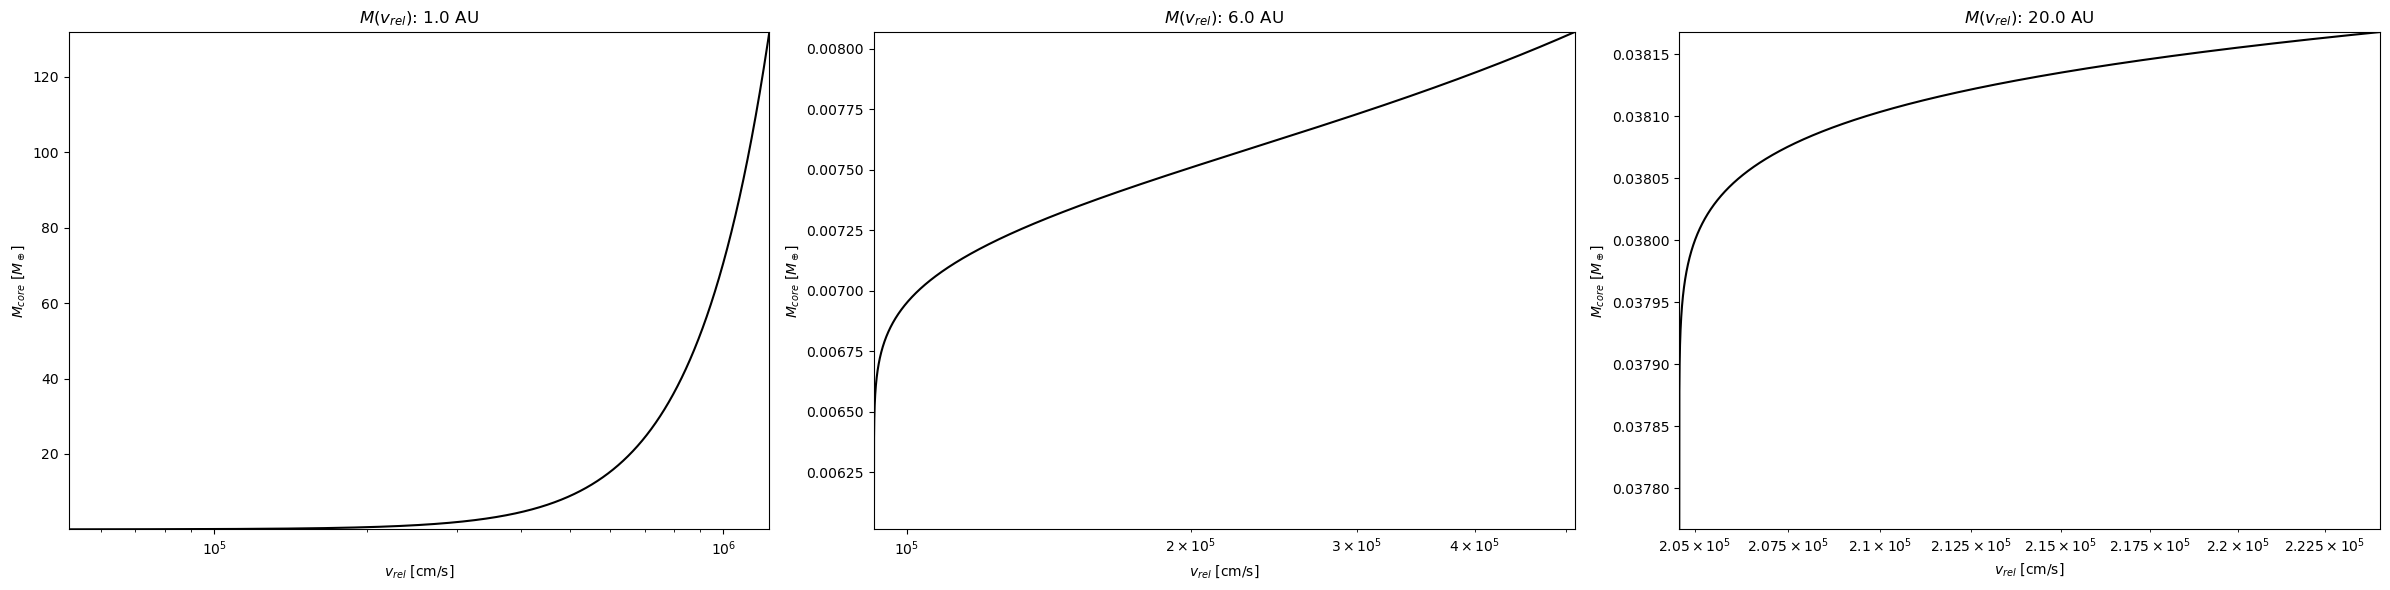

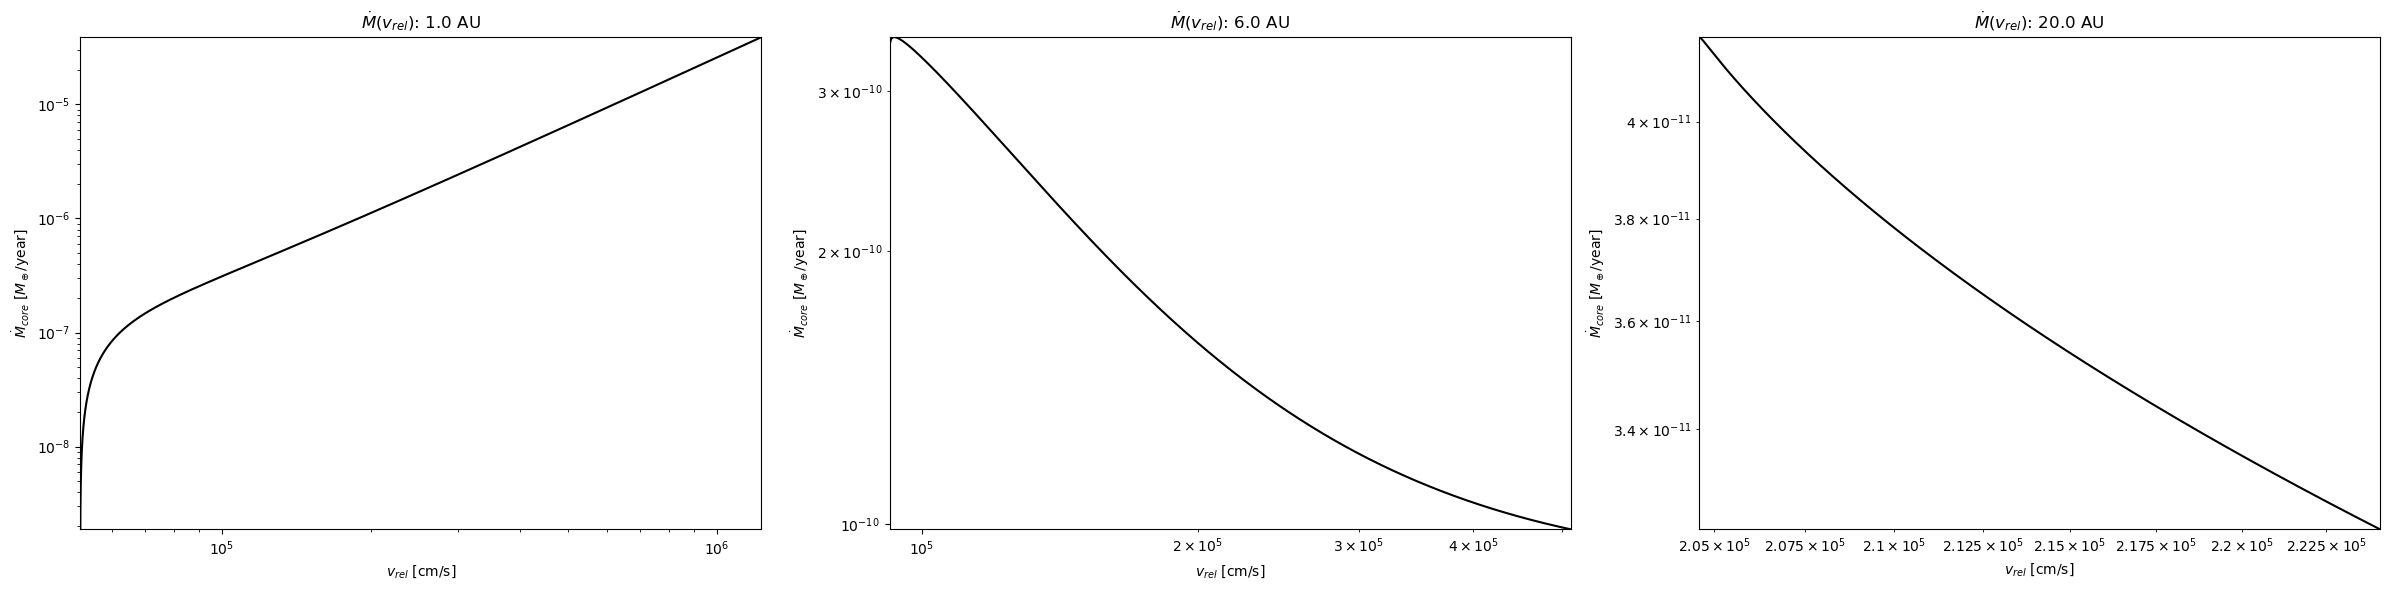

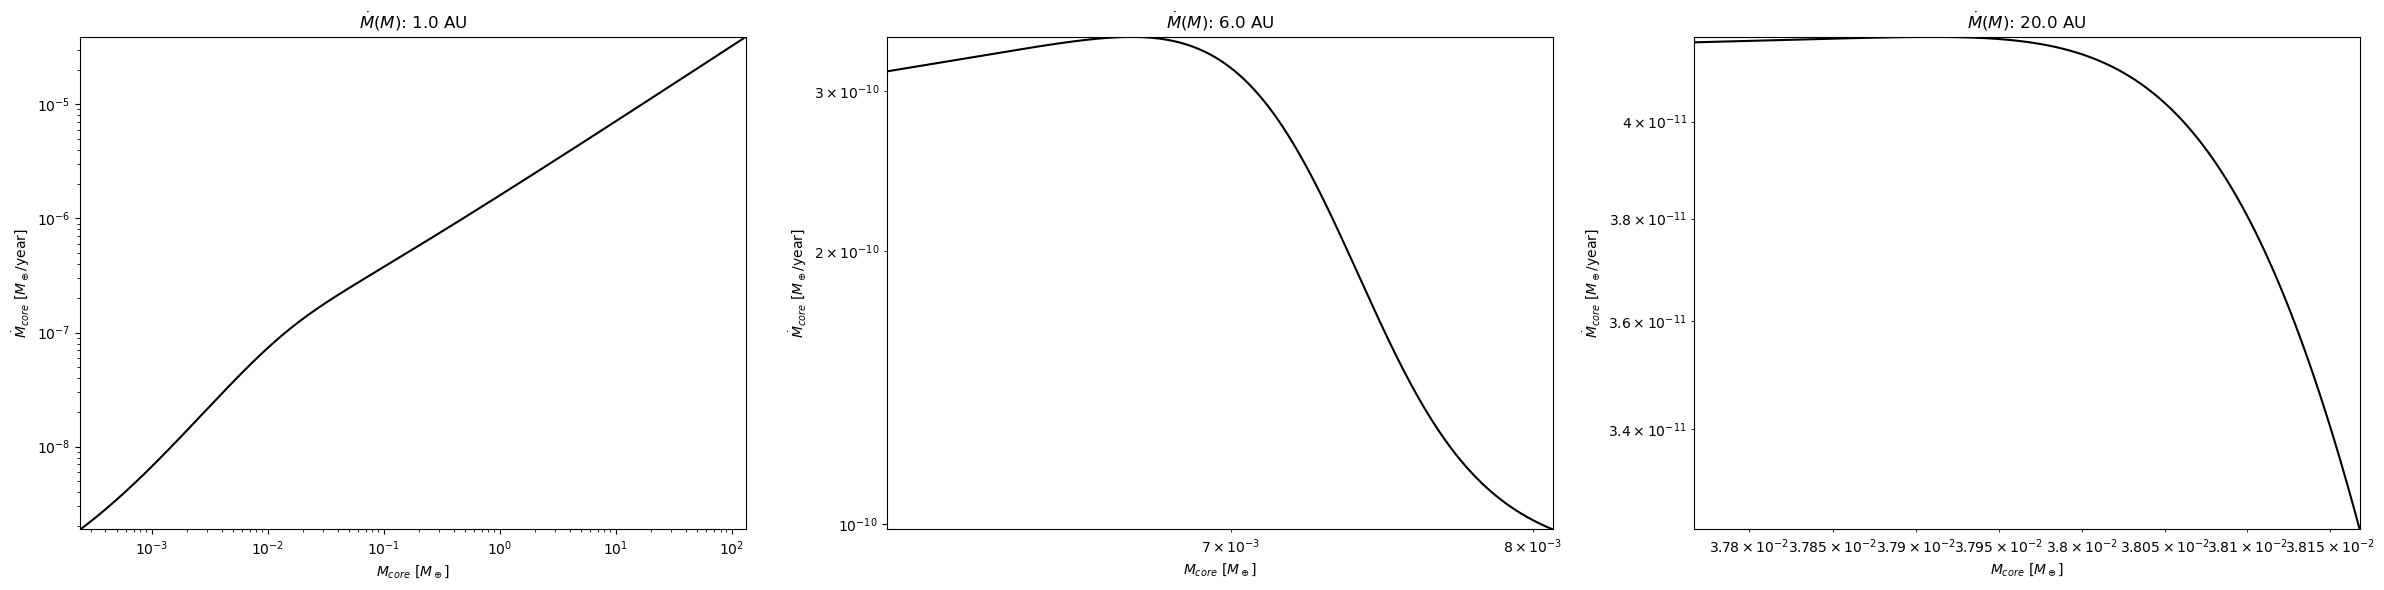

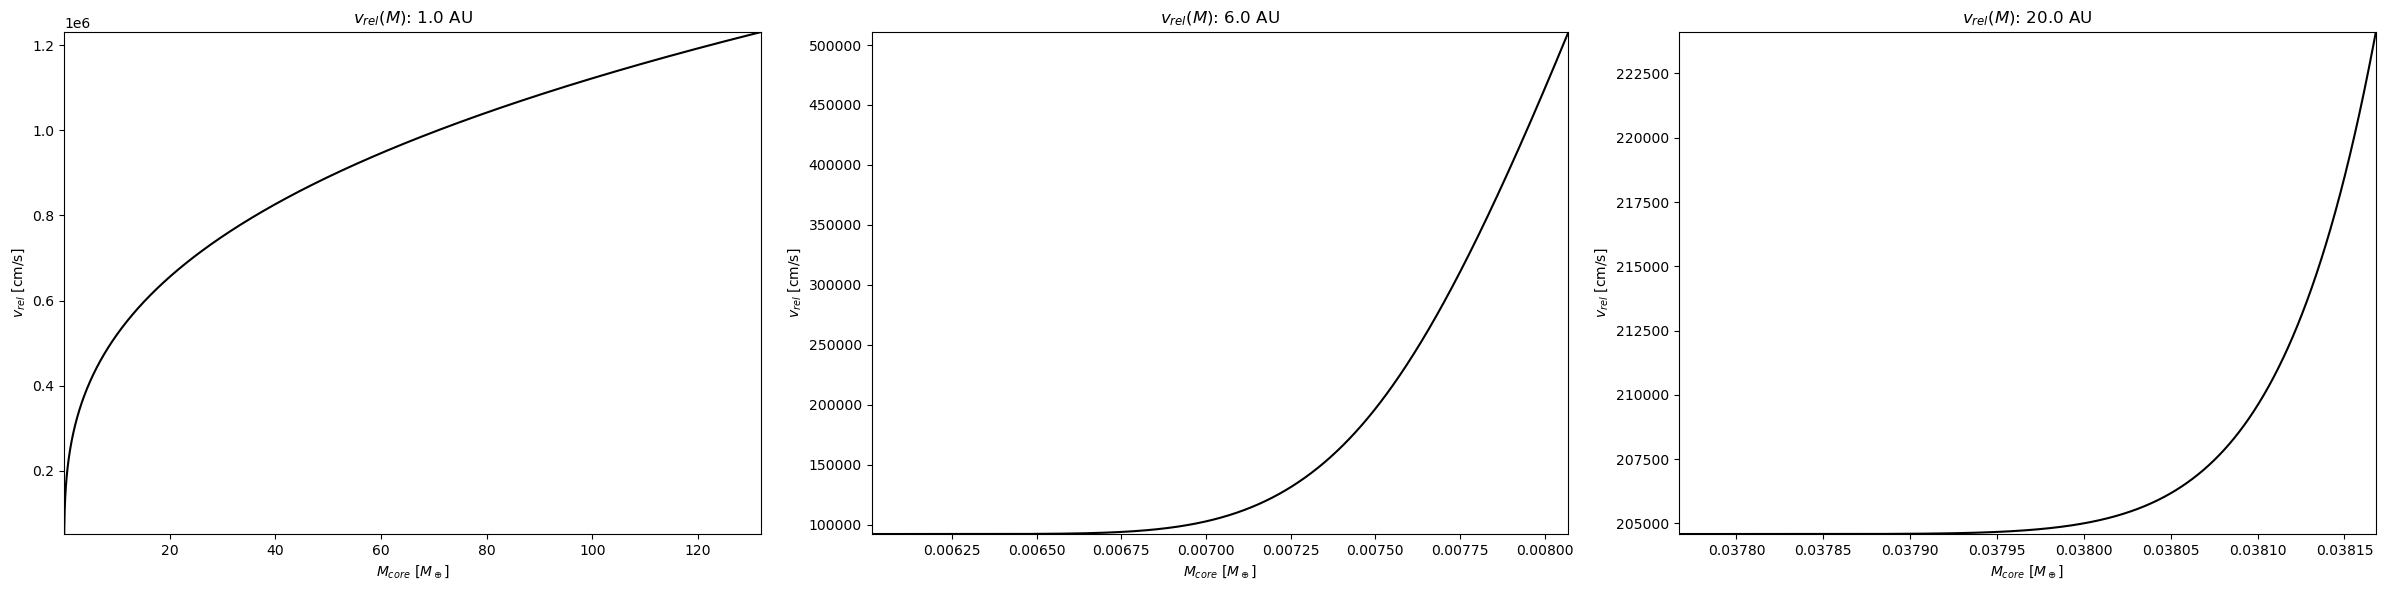

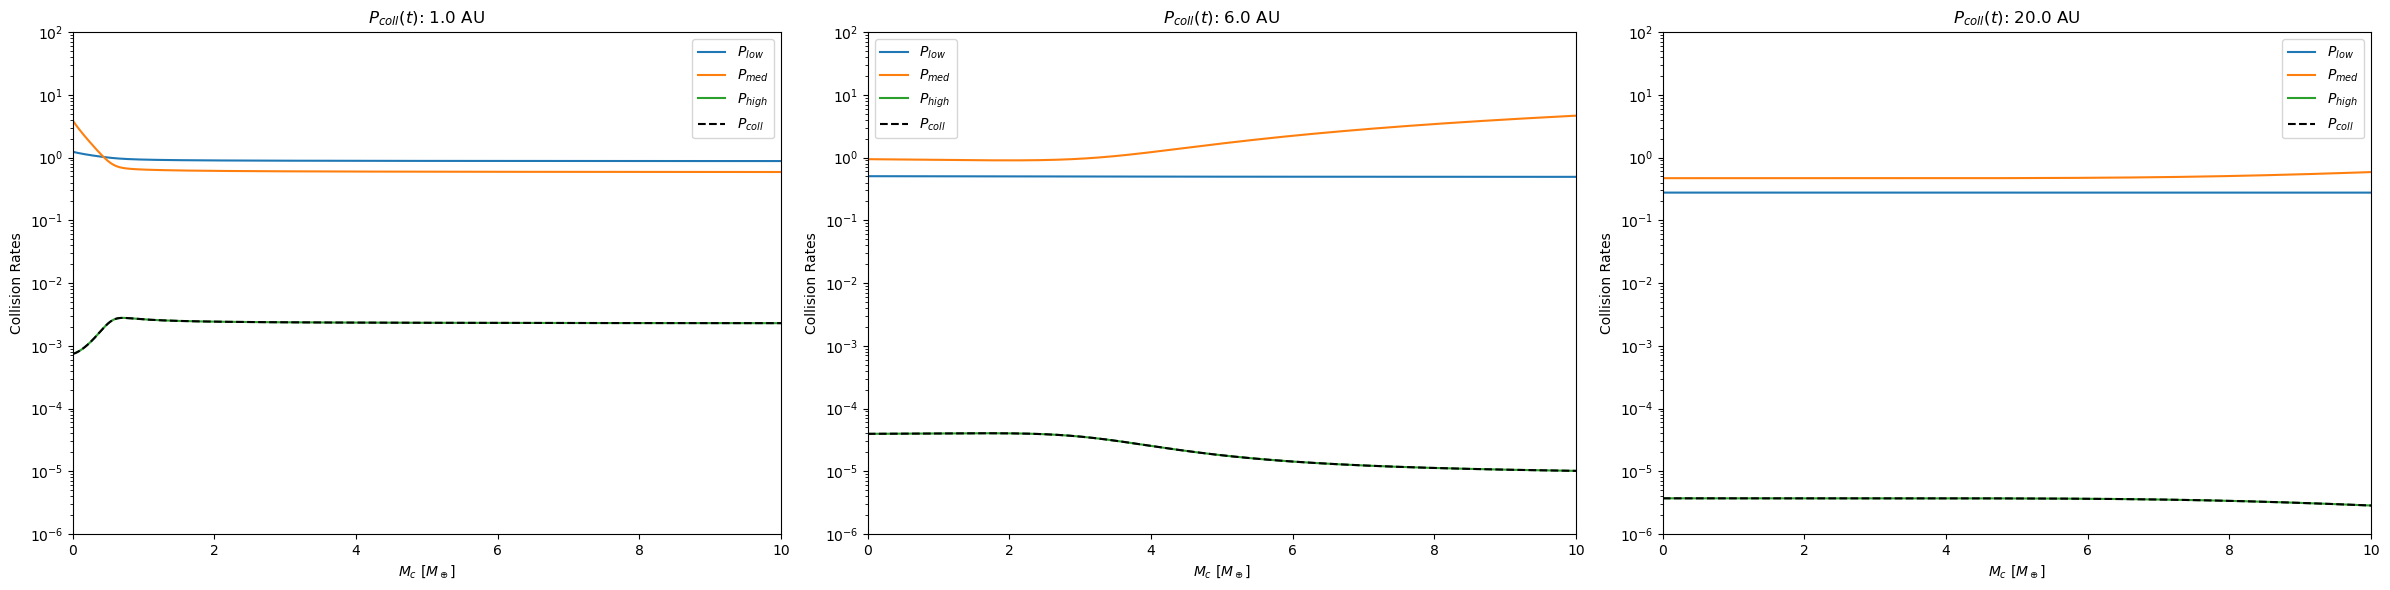

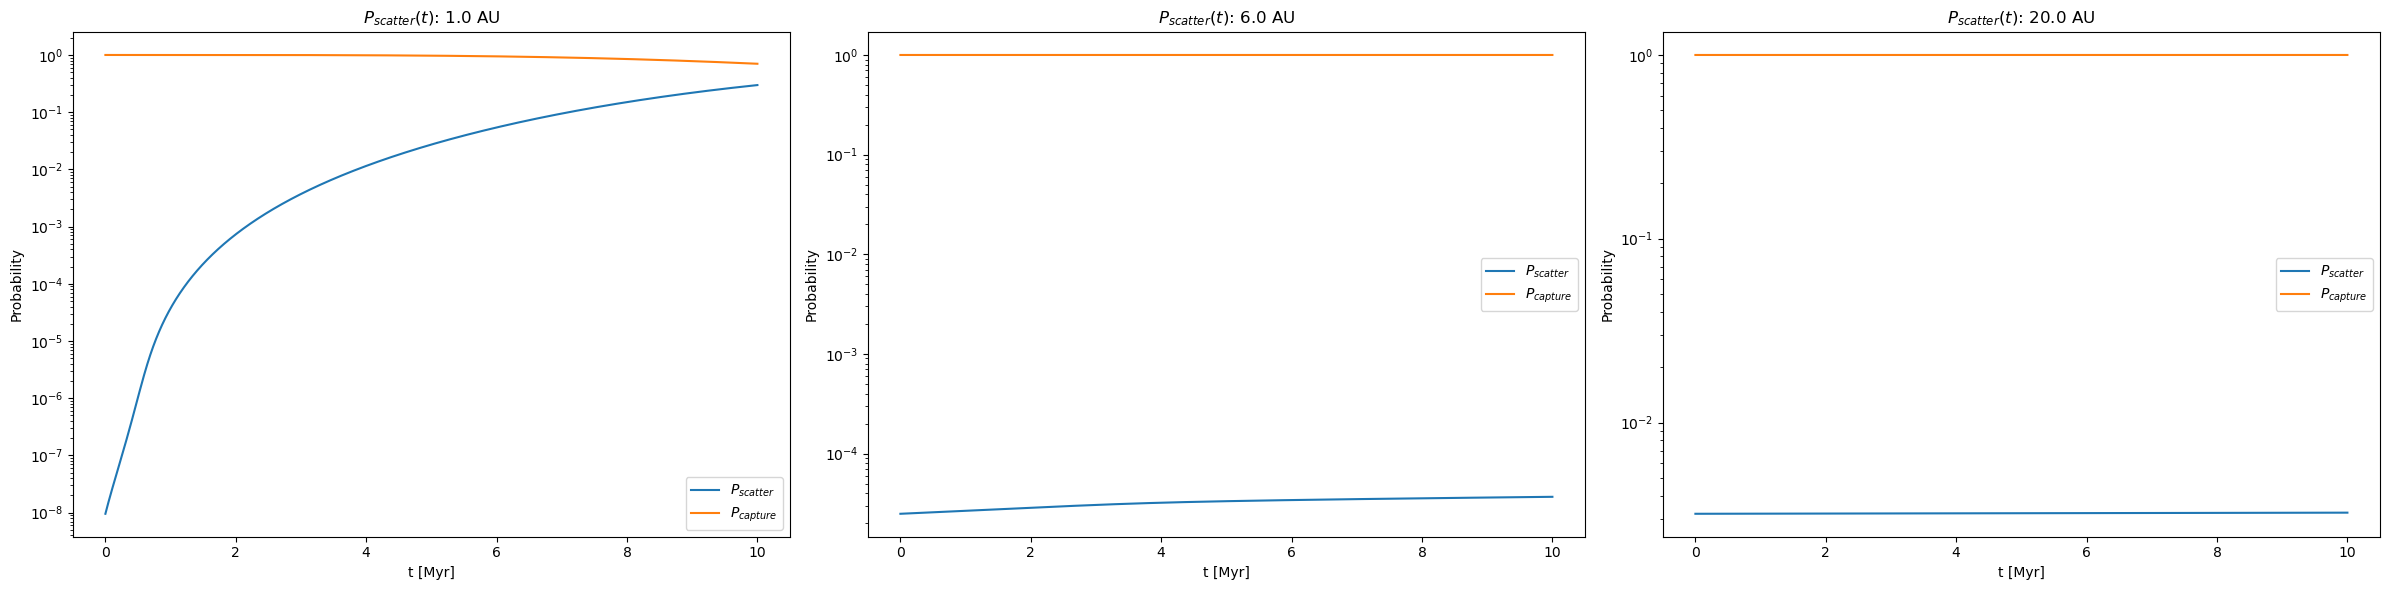

In [ ]:
## Load eccentricity and mass evolution

drag = True
VS_embryo = True
VS_pltsml = True
DF = True
accretion = True
scatter = False

a_cores = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0]) # AU
M_disk = 0.1 # M_sun
t_end = 10.0 # Myr
t_interval = 1000 # years

filename = f'ncores_{len(a_cores)}_Mdisk_{M_disk}_tend_{t_end}'

output_dir = f'/path/to/outputs/{filename}.h5'
figure_dir = f'/path/to/figures/{filename}/Extra Plots/'

if not(os.path.exists(figure_dir)):
        os.makedirs(figure_dir)

## Check for existing results file

if os.path.exists(output_dir):
    print(f'Loading results from "{output_dir}"...')

    with h5py.File(output_dir, "r") as h5f:
        results = load_results(output_dir)

    ## Plot results for a_vals

    a_vals = [1.0, 6.0, 20.0]

    print(f'Plotting results and saving figures to "{figure_dir}"...')
    extra_plots(a_vals, results, figure_dir)

else:
    print(f'File not found: "{output_dir}"')